# Clausius Clapeyron

In [1]:
# load libraries and get data:
import numpy as np
import matplotlib.pyplot as plt

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'

print("done.")

done.


## 3) Saturation specific humidity:

Plot the saturation specific humidity (gr water vapor per gram moist air) as function of SST, for the observed MDR SST and for the MDR-averaged SST increase projected by 2100 under the RCP8.5 scenario.

T= 283.15 , q*= 7.804966956554264 , alpha= 0.06703971993131842
T= 303.15 , q*= 27.56247192758558 , alpha= 0.05739998561951916


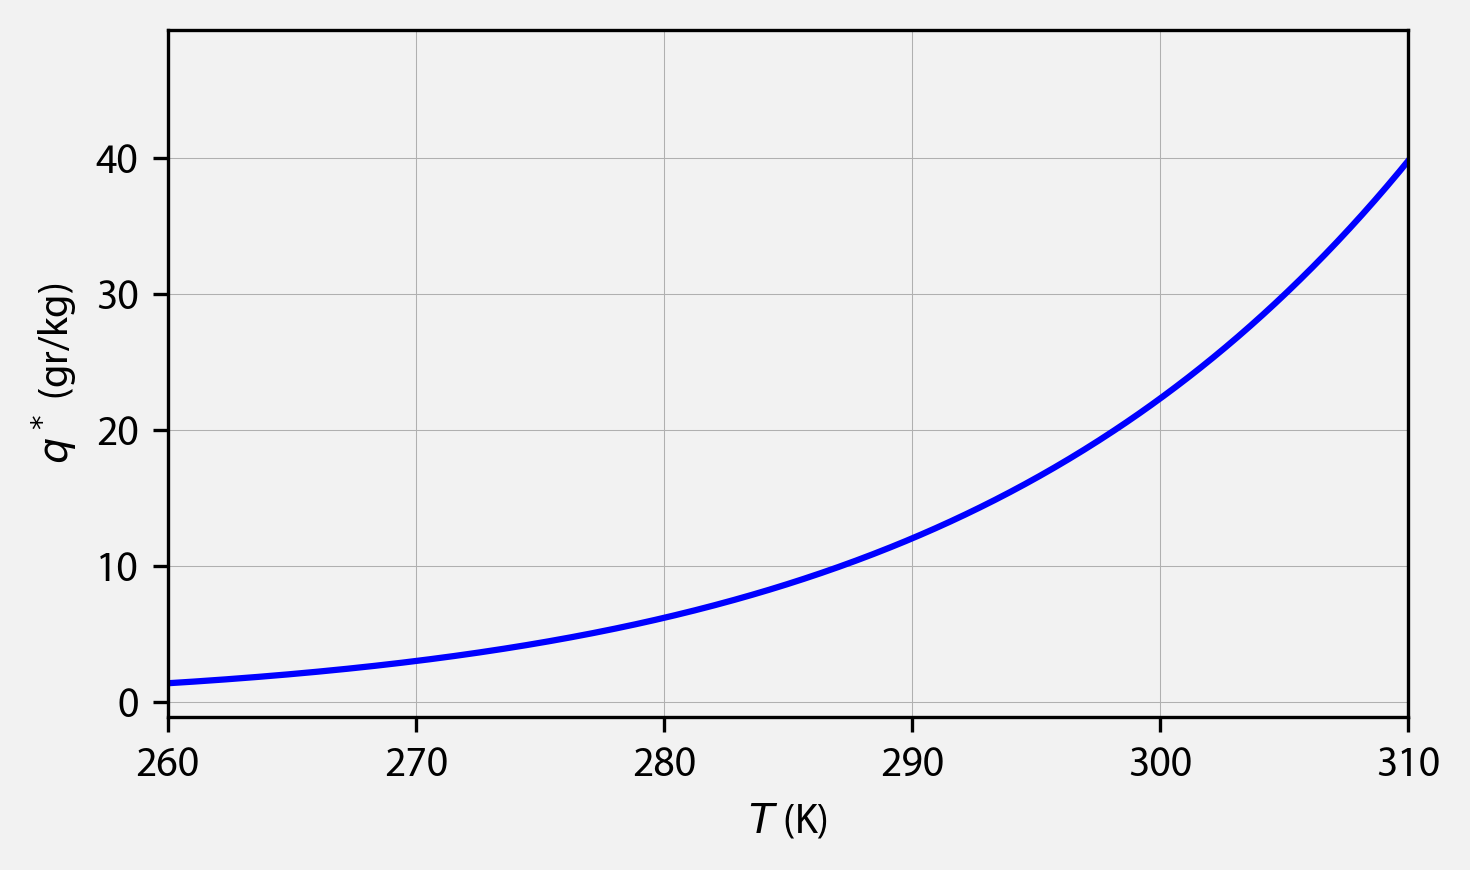

In [2]:
R_v = 461 # Gas constant for moist air = 461 J/(kg*K)
R_d = 287 # Gas constant 287 J K^-1 kg^-1
L = 2250

def q_sat(T,P):
    # saturation specific humidity (gr water vapor per gram moist air):
    # inputs:
    # T: temperature, in Kelvin
    # P: pressure, in mb

    TT = T-273.15 # Kelvin to Celsius
    # Saturation water vapor pressure (mb) from Emanuel 4.4.14 p 116-117: 
    ew = 6.112*np.exp((17.67 * TT) / (TT + 243.5))
    # saturation mixing ratio (gr water vapor per gram dry air):
    rw = (R_d / R_v) * ew / (P - ew)
    # saturation specific humidity (gr water vapor per gram moist air):
    qw = rw / (1 + rw)
    return qw

def L_v(T):
    # input: T=temperature in Kelvin.
    # Gill appendix 4, page 607
    T_Celsius=T-273.15;
    Lv=2.5008e6-2.3e3*T_Celsius;
    return Lv

# calculate for plotting saturation moisture as function of temperature:
T_plot=np.arange(-15.0,40.0,0.1)+273.15
q_plot=T_plot*0.0
q_plot_approx=T_plot*0.0
alpha_plot=T_plot*0.0
for i in range(0,len(T_plot)):
    q_plot[i]=q_sat(T_plot[i],1000)
    q_plot_approx[i]=2.541e6*np.exp(-5415/T_plot[i])*18/29
    alpha_plot[i]=L_v(T_plot[i])/(R_v*T_plot[i]**2)


# Plot:
# -----
fig=plt.figure(figsize=(5,3),dpi=300)

#plt.subplot(1,2,1)
plt.plot(T_plot,q_plot*1000,color="blue",ls="-")
##plt.plot(T_plot,q_plot_approx*1000,color="blue",ls="--")
plt.ylabel("$q^*$ (gr/kg)")
plt.xlabel("$T$ (K)");
plt.xlim(260,310)
plt.grid(lw=0.25)
ax=plt.gca()
ax.set_facecolor('#f2f2f2')
fig.patch.set_facecolor('#f2f2f2')
plt.tight_layout()

fig.savefig("Output/greenhouse-Clausius-Clapeyron.pdf",format='pdf',facecolor='#f2f2f2');

# sumple values:
T=10+273.15;
alpha=L_v(T)/(R_v*T**2)
print("T=",T,", q*=",2.541e9*np.exp(-5415/T)*18/29,", alpha=",alpha);
T=30+273.15;
alpha=L_v(T)/(R_v*T**2)
print("T=",T,", q*=",2.541e9*np.exp(-5415/T)*18/29,", alpha=",alpha);

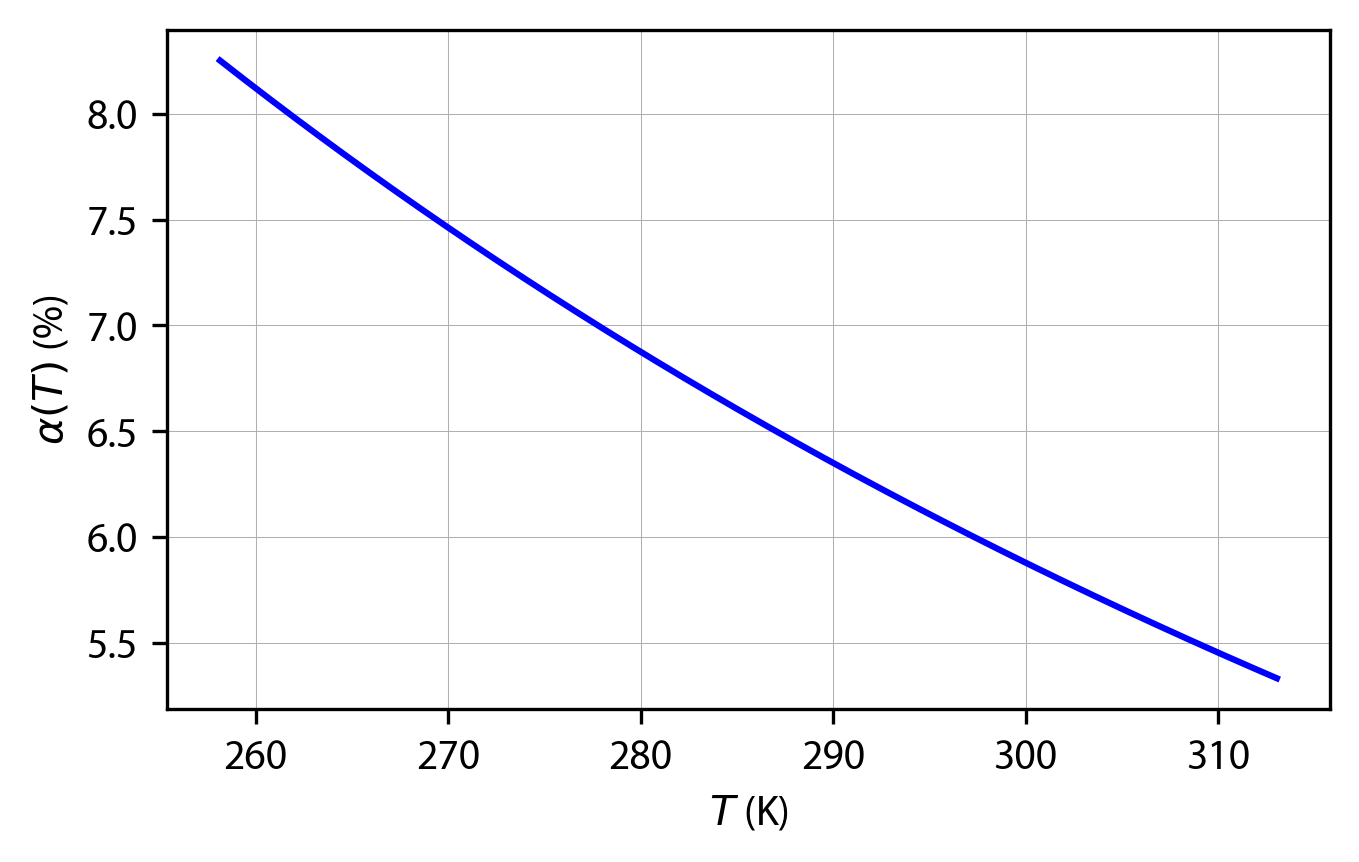

In [3]:
fig=plt.figure(figsize=(5,3),dpi=300)

plt.plot(T_plot,alpha_plot*100,color="blue",ls="-")
plt.xlabel("$T$ (K)");
plt.ylabel("$\\alpha(T)$ (%)")
plt.grid(lw=0.25)